In [1]:
from unet import *
import tensorflow as tf 
from collections import defaultdict


# --- Aggregate tile pairs from a list of sites ---
def aggregate_tile_pairs(sites, folder_path):
    """
    Aggregates all tile pairs from the provided sites.
    Each pair is a tuple: (img_path, mask_path, snow_ratio)
    """
    img_paths = glob.glob(os.path.join(folder_path, "*_img.npy"))
    tile_pairs = []
    for ip in img_paths:
        site = os.path.basename(ip).split("_")[0]
        if site in sites:
            mp = ip.replace("_img.npy", "_msk.npy")
            if os.path.exists(mp):
                # Compute snow ratio
                mask = np.load(mp)
                ratio = np.mean(mask)
                tile_pairs.append((ip, mp, ratio))
    return tile_pairs

# --- Bin tile pairs by snow ratio ---
def bin_tile_pairs(tile_pairs, snow_vs_notsnow_ratio_distribution):
    """
    Bins tile pairs (list of (img_path, mask_path, ratio)) into low, mid, and high lists.
    snow_vs_notsnow_ratio_distribution: (high_threshold, low_threshold)
    """
    high_threshold = snow_vs_notsnow_ratio_distribution[0]  # e.g. 0.8
    low_threshold = snow_vs_notsnow_ratio_distribution[1]   # e.g. 0.2
    
    low_bin = [(img, msk) for img, msk, ratio in tile_pairs if ratio <= low_threshold]
    high_bin = [(img, msk) for img, msk, ratio in tile_pairs if ratio >= high_threshold]
    mid_bin = [(img, msk) for img, msk, ratio in tile_pairs if low_threshold < ratio < high_threshold]
    
    random.shuffle(low_bin)
    random.shuffle(mid_bin)
    random.shuffle(high_bin)
    return low_bin, mid_bin, high_bin



def uniform_sample_by_ratio(tile_pairs, num_bins=100, seed=None):
    """
    Given tile_pairs [(img, mask, ratio), …], split into num_bins bins by ratio,
    then sample from each bin the size of the smallest bin, returning a flat list.
    """
    if seed is not None:
        random.seed(seed)

    # 1) Assign each pair to a bin index 0..num_bins-1
    bins = defaultdict(list)
    for img_path, mask_path, ratio in tile_pairs:
        # ensure ratio in [0,1]
        r = min(max(ratio, 0.0), 1.0)
        # bin width = 1/num_bins; ratio* num_bins gives [0, num_bins]
        idx = min(int(r * num_bins), num_bins - 1)
        bins[idx].append((img_path, mask_path, ratio))

    # 2) Find smallest bin size
    sizes = [ len(bins[i]) for i in range(num_bins) ]
    min_size = min(sizes)
    print(f"Bin counts: {sizes}")
    print(f"→ Sampling {min_size} tiles from each of {num_bins} bins → total {min_size * num_bins}")

    # 3) Sample min_size from each bin
    balanced = []
    for i in range(num_bins):
        group = bins[i]
        # if a bin has exactly min_size, random.sample works
        sampled = random.sample(group, min_size)
        balanced.extend(sampled)

    # 4) Shuffle the final list so you don’t train in sorted‐by‐ratio order
    random.shuffle(balanced)
    return balanced


# --- Sampling from bins ---
def sample_from_bins(low_bin, mid_bin, high_bin, target_number, mid_low_high_ratio_distribution):
    """
    Samples tile pairs from each bin according to the provided distribution.
    mid_low_high_ratio_distribution: (mid_ratio, low_ratio, high_ratio)
    """
    mid_ratio, low_ratio, high_ratio = mid_low_high_ratio_distribution
    required_mid = int(target_number * mid_ratio)
    required_low = int(target_number * low_ratio)
    required_high = int(target_number * high_ratio)
    
    if len(mid_bin) < required_mid:
        print(f"Limiting factor for mid bin: required {required_mid}, available {len(mid_bin)}")
    if len(low_bin) < required_low:
        print(f"Limiting factor for low bin: required {required_low}, available {len(low_bin)}")
    if len(high_bin) < required_high:
        print(f"Limiting factor for high bin: required {required_high}, available {len(high_bin)}")
    
    actual_mid = min(len(mid_bin), required_mid)
    actual_low = min(len(low_bin), required_low)
    actual_high = min(len(high_bin), required_high)
    
    sampled_mid = mid_bin[:actual_mid]
    sampled_low = low_bin[:actual_low]
    sampled_high = high_bin[:actual_high]
    
    # Remove sampled items to avoid re-use if needed.
    del mid_bin[:actual_mid]
    del low_bin[:actual_low]
    del high_bin[:actual_high]
    
    sampled_tiles = sampled_mid + sampled_low + sampled_high
    random.shuffle(sampled_tiles)
    return sampled_tiles

def run_unet_training(
    folder_path,
    balanced_train_pairs,
    in_sample_val_tiles,
    in_sample_test_tiles,
    out_of_sample_test_tiles,
    img_height,
    img_width,
    img_channels,
    batch_size,
    epochs,
    comet_api_key,
    comet_project_name,
    comet_workspace,
    model_instance_name
):
    """
    Train a U-Net on a pre-balanced tile list using tf.data.Datasets and the existing train_model.

    Args:
      folder_path: (unused here) original data folder path
      balanced_train_pairs: list of (img_path, mask_path, ratio) uniformly sampled across 100 bins
      in_sample_val_tiles: list of (img_path, mask_path, ratio) for in-sample validation
      in_sample_test_tiles: list of (img_path, mask_path, ratio) for in-sample testing
      out_of_sample_test_tiles: list of (img_path, mask_path, ratio) for out-of-sample testing
      img_height, img_width, img_channels: input dimensions
      batch_size: training batch size
      epochs: number of epochs
      comet_api_key, comet_project_name, comet_workspace: Comet.ml settings
      model_instance_name: name for this experiment/run

    Returns:
      model, history, in_sample_eval_results, out_of_sample_eval_results
    """
    # Initialize Comet experiment
    experiment = Experiment(
        api_key=comet_api_key,
        project_name=comet_project_name,
        workspace=comet_workspace
    )
    experiment.set_name(model_instance_name)

    # Build the U-Net model
    model = unet_model(
        n_classes=1,
        img_height=img_height,
        img_width=img_width,
        img_channels=img_channels
    )

    # Prepare tf.data datasets
    train_ds = make_dataset(
        balanced_train_pairs,
        batch_size=batch_size,
        shuffle=True
    )
    val_ds = make_dataset(
        in_sample_val_tiles,
        batch_size=batch_size,
        shuffle=False
    )
    test_in_ds = make_dataset(
        in_sample_test_tiles,
        batch_size=batch_size,
        shuffle=False
    )
    test_out_ds = make_dataset(
        out_of_sample_test_tiles,
        batch_size=batch_size,
        shuffle=False
    )

    # Dataset info for callbacks and logging
    dataset_info = {
        'num_train_samples': len(balanced_train_pairs),
        'num_val_samples': len(in_sample_val_tiles),
        'num_test_in_samples': len(in_sample_test_tiles),
        'num_test_out_samples': len(out_of_sample_test_tiles),
    }

    # Format date for saving
    date_str = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    # Train the model (compiling, fitting, saving are inside train_model)
    model, history = train_model(
        unet_model=model,
        train_dataset=train_ds,
        val_dataset=val_ds,
        date_str=date_str,
        dataset_info=dataset_info,
        batch_size=batch_size,
        epochs=epochs,
        experiment=experiment,
        instance_name=model_instance_name
    )

    # Evaluate on both in-sample and out-of-sample test sets
    in_sample_eval_results = model.evaluate(test_in_ds, return_dict=True)
    # Log in-sample metrics to Comet
    experiment.log_metric("in_sample_testing_combined_loss", in_sample_eval_results.get("loss"))
    experiment.log_metric("in_sample_testing_dice_coef", in_sample_eval_results.get("dice_coef"))

    out_of_sample_eval_results = model.evaluate(test_out_ds, return_dict=True)
    # Log out-of-sample metrics to Comet
    experiment.log_metric("out_of_sample_testing_combined_loss", out_of_sample_eval_results.get("loss"))
    experiment.log_metric("out_of_sample_testing_dice_coef", out_of_sample_eval_results.get("dice_coef"))

    # End the Comet experiment
    experiment.end()

    return model, history, in_sample_eval_results, out_of_sample_eval_results

In [2]:
# Comet ML and Hyperparameters that are the same for all models
folder_path = r"C:\Users\jaydb\Snowpack_Project\Tiled_Output"

comet_api_key = "HMIpeLQjlVPMeWB9fDhY9Pv11"
comet_project_name = "unet-snow-model"
comet_workspace = "reversedpuppy"

IMG_HEIGHT = 512
IMG_WIDTH = 512
IMG_CHANNELS = 3

max_training_tiles = 22000

In [3]:
#Generate In sample and out of sample Validation and Testing tiles sets

training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy"]
testing_sites = ["StrandHill", "VirginiaBasin"]

max_in_sample_validation_tiles = 4400
max_in_sample_testing_tiles = 2200
max_out_of_sample_testing_tiles = 2200

# Aggregate pairs.
all_training_pairs = aggregate_tile_pairs(training_sites, folder_path)
all_testing_pairs = aggregate_tile_pairs(testing_sites, folder_path)
print(f"Total aggregated training pairs: {len(all_training_pairs)}")
print(f"Total aggregated testing pairs (out-of-sample): {len(all_testing_pairs)}")

# --- Split training pairs into 70% (for training) and 30% (for in-sample validation+testing) ---
train_split, in_sample_split = train_test_split(all_training_pairs, test_size=0.3, random_state=42)
print(f"70% training split count: {len(train_split)}")
print(f"30% in-sample split count: {len(in_sample_split)}")

# --- From the in-sample split, sample fixed numbers for validation and testing ---
total_in_sample = len(in_sample_split)
if max_in_sample_validation_tiles + max_in_sample_testing_tiles <= total_in_sample:
    shuffled = random.sample(in_sample_split, total_in_sample)
    in_sample_val_tiles = shuffled[:max_in_sample_validation_tiles]
    in_sample_test_tiles = shuffled[max_in_sample_validation_tiles:max_in_sample_validation_tiles+max_in_sample_testing_tiles]
else:
    in_sample_val_tiles = random.sample(in_sample_split, min(max_in_sample_validation_tiles, total_in_sample))
    in_sample_test_tiles = random.sample(in_sample_split, min(max_in_sample_testing_tiles, total_in_sample))
print(f"In-sample validation tiles count: {len(in_sample_val_tiles)}")
print(f"In-sample testing tiles count: {len(in_sample_test_tiles)}")

# --- Out-of-sample testing: sample from testing pairs ---
out_of_sample_test_tiles = random.sample(all_testing_pairs, min(len(all_testing_pairs), max_out_of_sample_testing_tiles))
print(f"Out-of-sample testing tiles count: {len(out_of_sample_test_tiles)}")

Total aggregated training pairs: 118039
Total aggregated testing pairs (out-of-sample): 18212
70% training split count: 82627
30% in-sample split count: 35412
In-sample validation tiles count: 4400
In-sample testing tiles count: 2200
Out-of-sample testing tiles count: 2200


In [4]:
balanced_train_pairs = uniform_sample_by_ratio(
    train_split,    # your 70% train_split of (img,mask,ratio)
    num_bins=100,
    seed=42
)

Bin counts: [54919, 697, 525, 437, 387, 342, 337, 256, 256, 251, 237, 245, 219, 200, 227, 210, 188, 162, 182, 181, 155, 142, 158, 144, 148, 147, 166, 151, 162, 157, 158, 132, 142, 145, 118, 142, 121, 131, 128, 117, 146, 126, 130, 138, 137, 129, 131, 113, 120, 99, 112, 119, 104, 150, 141, 115, 114, 135, 134, 109, 126, 111, 106, 113, 141, 116, 135, 128, 122, 136, 147, 131, 129, 142, 137, 127, 147, 154, 154, 155, 137, 178, 130, 161, 150, 162, 169, 172, 191, 194, 203, 211, 237, 255, 263, 320, 336, 441, 558, 9678]
→ Sampling 99 tiles from each of 100 bins → total 9900


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/4267c1c2d1c44c9b9790c9f62bb4d4b3



Model summary:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 512, 512, 16  432         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 512, 512, 16  64         ['conv2d[0][0]']                 
 alization)                     )                                              

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging
COMET INFO: Ignoring automatic log_parameter('verbose') because 'keras:verbose' is in COMET_LOGGING_PARAMETERS_IGNORE


Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


619/619 [==============================] - ETA: 0s - loss: 0.7975 - accuracy: 0.9397 - precision: 0.9383 - recall: 0.9411 - dice_coef: 0.9106   
Epoch 1: val_loss improved from inf to 0.15546, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
619/619 [==============================] - 270s 420ms/step - loss: 0.7975 - accuracy: 0.9397 - precision: 0.9383 - recall: 0.9411 - dice_coef: 0.9106 - val_loss: 0.1555 - val_accuracy: 0.9765 - val_precision: 0.9260 - val_recall: 0.9742 - val_dice_coef: 0.8408
Epoch 2/20
619/619 [==============================] - ETA: 0s - loss: 0.1306 - accuracy: 0.9458 - precision: 0.9430 - recall: 0.9489 - dice_coef: 0.9281  
Epoch 2: val_loss did not improve from 0.15546
Epoch 2: learning_rate = 0.000954
619/619 [==============================] - 230s 371ms/step - loss: 0.1306 - accuracy: 0.9458 - precision: 0.9430 - recall: 0.9489 - dic

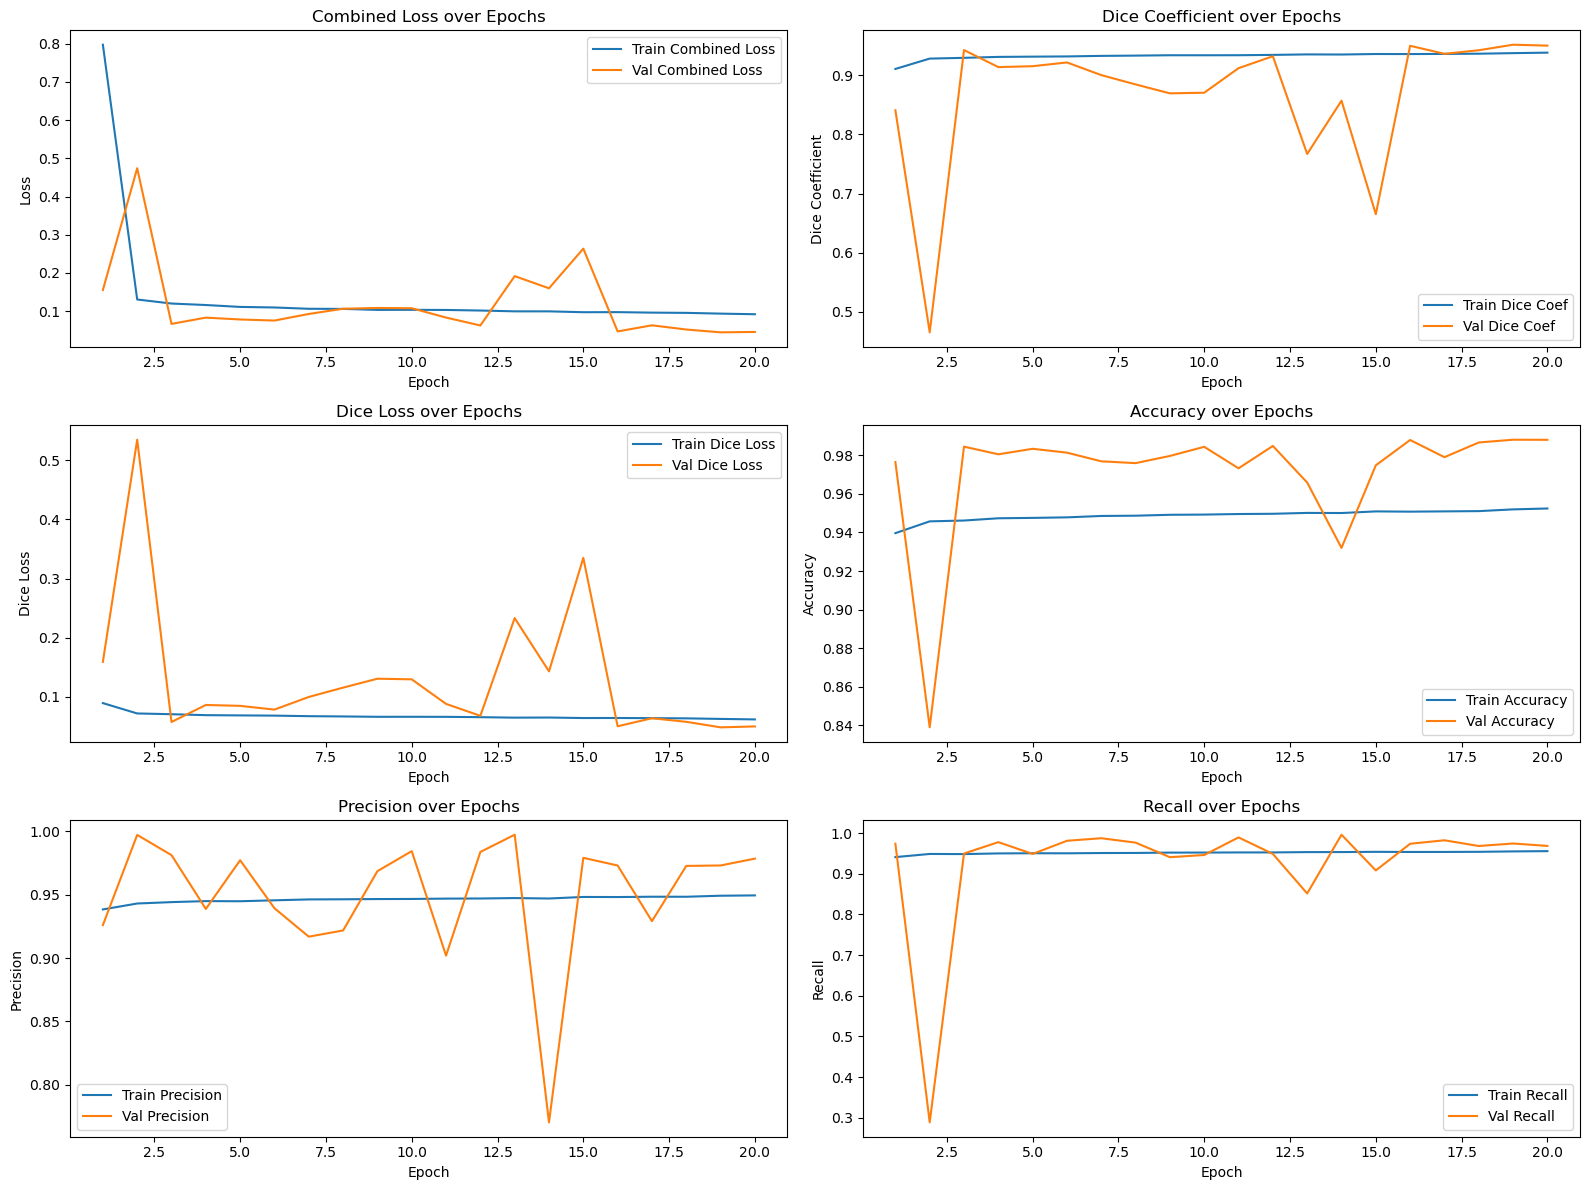


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Uniform.2_20250422-175531\Model_Data
138/138 [==============================] - 30s 217ms/step - loss: 0.0683 - accuracy: 0.9874 - precision: 0.9595 - recall: 0.9588 - dice_coef: 0.9076


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Uniform.2
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/4267c1c2d1c44c9b9790c9f62bb4d4b3
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                       : (0.939652681350708, 0.9524503350257874)
COMET INFO:     batch_accuracy [1240]               : (0.5818254947662354, 0.9641976356506348)
COMET INFO:     batch_dice_coef [1240]              : (0.5113282799720764, 0.9583765864372253)
COMET INFO:     batch_loss [1240]                   : (0.06999929994344711, 47.08004379272461)
COMET INFO:     batch_precision [1240]              : (0.6497925519943237, 0.9799219965934753)
COMET I

In [5]:
# Distribution for sampling training bins.

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Uniform.2"

# Run training.
model, history, in_sample_eval, out_of_sample_eval = run_unet_training(
    folder_path=folder_path,
    balanced_train_pairs=balanced_train_pairs,
    in_sample_val_tiles=in_sample_val_tiles,
    in_sample_test_tiles=in_sample_test_tiles,
    out_of_sample_test_tiles=out_of_sample_test_tiles,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)